In [212]:
import pandas as pd
import scipy.stats
import seaborn as sn
import matplotlib.pyplot as plt
import statsmodels.formula.api as sm
from stargazer.stargazer import Stargazer
from IPython.core.display import HTML
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RepeatedKFold, cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np
from numpy import mean
from numpy import absolute
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV






In [213]:
data=pd.read_csv('/Users/melanyalegre/Documents/International Business/Minor documents/Data Modelling/1645634boston.csv')
data.head()

,MEDV,CRIM,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LANDMARK
0,300,51.13580,18.10,no,0.597,5.757,100.0,1.4130,24,666,20.2,No Landmark
1,230,8.15174,18.10,no,0.700,5.390,98.9,1.7281,24,666,20.2,No Landmark
2,278,15.28800,18.10,no,0.671,6.649,93.3,1.3449,24,666,20.2,No Landmark
3,424,0.23912,9.69,no,0.585,6.019,65.3,2.4091,6,391,19.2,No Landmark
4,270,1.61282,8.14,no,0.538,6.096,96.9,3.7598,4,307,21.0,No Landmark


Correlation Matrix & Heatmap

In [214]:
data=data[['MEDV','RM','AGE']]
matrix=data.corr()
print(matrix)

          MEDV        RM       AGE
MEDV  1.000000  0.733064 -0.386466
RM    0.733064  1.000000 -0.234385
AGE  -0.386466 -0.234385  1.000000


<Axes: >

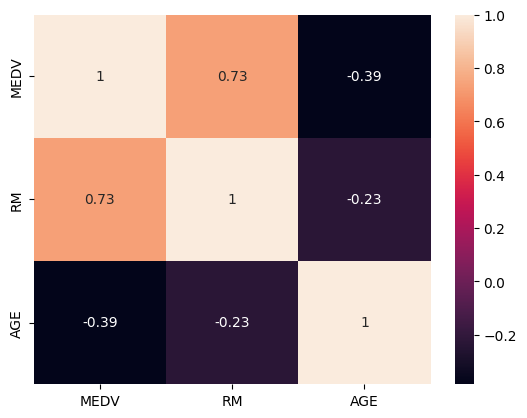

In [215]:
sn.heatmap(matrix,annot=True)

Regression Model

In [216]:
df=pd.get_dummies(df, dtype=int)
df.head()

,MEDV,CRIM,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,CHAS_no,CHAS_yes,LANDMARK_Museum,LANDMARK_No_Landmark,LANDMARK_Park,LANDMARK_Shopping_Mall,LANDMARK_Stadium
0,300,51.13580,18.10,0.597,5.757,100.0,1.4130,24,666,20.2,1,0,0,1,0,0,0
1,230,8.15174,18.10,0.700,5.390,98.9,1.7281,24,666,20.2,1,0,0,1,0,0,0
2,278,15.28800,18.10,0.671,6.649,93.3,1.3449,24,666,20.2,1,0,0,1,0,0,0
3,424,0.23912,9.69,0.585,6.019,65.3,2.4091,6,391,19.2,1,0,0,1,0,0,0
4,270,1.61282,8.14,0.538,6.096,96.9,3.7598,4,307,21.0,1,0,0,1,0,0,0


In [217]:
df.columns = df.columns.str.replace(' ', '_')
df.columns

Index(['MEDV', 'CRIM', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'CHAS_no', 'CHAS_yes', 'LANDMARK_Museum',
       'LANDMARK_No_Landmark', 'LANDMARK_Park', 'LANDMARK_Shopping_Mall',
       'LANDMARK_Stadium'],
      dtype='object')

In [218]:
model_1 = sm.ols('MEDV ~ CRIM + INDUS + NOX + RM + AGE + DIS + RAD + TAX + PTRATIO + CHAS_no + CHAS_yes+ LANDMARK_Museum + LANDMARK_No_Landmark + LANDMARK_Park + LANDMARK_Shopping_Mall + LANDMARK_Stadium', data=df).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.890
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     253.2
Date:                Mon, 20 Oct 2025   Prob (F-statistic):          2.54e-200
Time:                        20:15:49   Log-Likelihood:                -2518.2
No. Observations:                 455   AIC:                             5066.
Df Residuals:                     440   BIC:                             5128.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

Checking for multicollinearity


In [219]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif 
from statsmodels.tools.tools import add_constant

X=df[[ 'CRIM', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'CHAS_yes', 'LANDMARK_No_Landmark', 'LANDMARK_Park', 'LANDMARK_Shopping_Mall', 'LANDMARK_Stadium']].dropna()
X=add_constant(X)

VIF_data=pd.DataFrame()
VIF_data['Variable']=X.columns
VIF_data['VIF']=[vif(X,i)
                 for i in range (len(X.columns))]
print(VIF_data)

                  Variable         VIF
0                    const  604.093490
1                     CRIM    1.895099
2                    INDUS    4.182688
3                      NOX    4.492071
4                       RM    2.212531
5                      AGE    2.786017
6                      DIS    3.576689
7                      RAD    7.394288
8                      TAX    8.429543
9                  PTRATIO    1.822294
10                CHAS_yes    1.094462
11    LANDMARK_No_Landmark   13.932159
12           LANDMARK_Park    7.437757
13  LANDMARK_Shopping_Mall    6.498547
14        LANDMARK_Stadium    2.169292


In [220]:
model_2 = sm.ols('MEDV ~ CRIM + INDUS + NOX + RM + AGE + DIS + RAD + TAX + PTRATIO + CHAS_yes + LANDMARK_Museum + LANDMARK_Park + LANDMARK_Shopping_Mall + LANDMARK_Stadium', data=df).fit()
print(model_2.summary())


                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.890
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     253.2
Date:                Mon, 20 Oct 2025   Prob (F-statistic):          2.54e-200
Time:                        20:15:50   Log-Likelihood:                -2518.2
No. Observations:                 455   AIC:                             5066.
Df Residuals:                     440   BIC:                             5128.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                558

APA Table

In [221]:
Table = Stargazer([model_1,model_2])

HTML(Table.render_html())

Standarized correlations

In [222]:
df_s = df.copy()
df_s[['CRIM', 'RM', 'MEDV']] = StandardScaler().fit_transform(df_s[['CRIM', 'RM', 'MEDV']])


In [223]:

model_3 = sm.ols('MEDV ~ CRIM + RM', data=df_s).fit()
print(model_3.summary())


                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.590
Model:                            OLS   Adj. R-squared:                  0.588
Method:                 Least Squares   F-statistic:                     325.2
Date:                Mon, 20 Oct 2025   Prob (F-statistic):           3.09e-88
Time:                        20:15:50   Log-Likelihood:                -442.78
No. Observations:                 455   AIC:                             891.6
Df Residuals:                     452   BIC:                             903.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     1.6e-16      0.030   5.31e-15      1.0

Assignment 3

In [224]:
df=df.dropna()
y=df['MEDV']
X=df.drop('MEDV', axis=1)
X=pd.get_dummies(X, drop_first=True)


In [235]:
#Linear regression
cv = RepeatedKFold(n_splits=5, random_state=420)

lm=LinearRegression()
lm_scores=cross_val_score(lm, X, y,
                            scoring='neg_mean_absolute_error',
                            cv=cv)

lmMAD = mean(-lm_scores)
print('The average prediction error with full data is: %0f'% lmMAD)

The average prediction error with full data is: 49.647924


Lasso and Ridge regression

In [246]:

columns = X.columns                         
scaler = MinMaxScaler()                       
X = scaler.fit_transform(X)                   
X = pd.DataFrame(X, columns=columns)    

In [247]:
  
#grid search with Lasso
alpha_range = np.arange(start=1,stop=100,step=0.5) 

cv = RepeatedKFold(n_splits=5, random_state=420) 
param = {'alpha':alpha_range} 
LassoModel = Lasso() 

LassoM = GridSearchCV(LassoModel, 
                      param_grid=param, 
                      scoring ='neg_mean_absolute_error', 
                      cv=cv) 

LassoM.fit(X,y)
print("Best alpha(Lasso): ", LassoM.best_params_['alpha']) 

Best alpha(Lasso):  1.0


In [241]:
#grid search with Ridge
alpha_range = np.arange(start=1,stop=5,step=0.1) 

cv = RepeatedKFold(n_splits=5, random_state=420) 
param = {'alpha':alpha_range} 
RidgeModel = Ridge() 

RidgeM = GridSearchCV(RidgeModel, 
                      param_grid=param, 
                      scoring ='neg_mean_absolute_error', 
                      cv=cv)

RidgeM.fit(X,y)
print("Best alpha (Ridge): ", RidgeM.best_params_['alpha'])


Best alpha (Ridge):  1.0


In [244]:
LassoModel = Lasso(alpha=1)
RidgeModel = Ridge(alpha=1)

cv = RepeatedKFold(n_splits=5, random_state=420)
scoreslasso = cross_val_score(LassoModel, X, y, scoring='neg_mean_absolute_error', cv=cv) 
scoresridge = cross_val_score(RidgeModel, X, y, scoring='neg_mean_absolute_error', cv=cv) 

print('the average prediction error of linear regression was 49.647924')
lassoMAE = mean(absolute(scoreslasso)) 
print('the average prediction error with lasso is: %0f' % lassoMAE) 
ridgeMAE = mean(absolute(scoresridge)) 
print('the average prediction error with ridge is: %0f' % ridgeMAE) 


the average prediction error of linear regression was 49.647924
the average prediction error with lasso is: 52.831912
the average prediction error with ridge is: 49.875159


Neural Networks

In [ ]:

import numpy as np
import tensorflow as tf
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import RepeatedKFold, cross_val_score
from numpy import mean

tf.random.set_seed(420) 

def create_baseline():
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(X.shape[1],)),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dense(1)
    ])
    model.compile(
        optimizer='adam',
        loss='mean_absolute_error',   # MAD/MAE
        metrics=['mae']
    )
    return model

estimator = KerasRegressor(
    model=create_baseline,
    epochs=100,
    batch_size=16,
    verbose=0
)

kfold = RepeatedKFold(n_splits=5, random_state=420)

results = cross_val_score(estimator, X, y,
                          scoring='neg_mean_absolute_error',
                          cv=kfold)

nn_MAD = mean(-results)
print('Average MAD (Neural Network, 5-fold CV): %.2f' % nn_MAD)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scikeras/wrappers.py:699: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  return type_of_target(y)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scikeras/wrappers.py:699: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  return type_of_target(y)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scikeras/wrappers.py:699: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  return type_of_target(y)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scikeras/wrappers.py:699: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  return type_of_target(y)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scikeras/wrappers.py:699: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  return type_of_target(y)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scikeras/wrappers.py:699: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  return type_of_target(y)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scikeras/wrappers.py:699: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  return type_of_target(y)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scikeras/wrappers.py:699: UserWarning: Th

Average MAD (Neural Network, 5-fold CV): 43.78
